## Web APIs for data 

files needed = None! (It's all coming from the cloud.)

We have been loading data from files using `pd.read_csv()` and `pd.read_excel()`. Another way to input data into pandas is by directly downloading data from a web server through an *application programming interface* or api. 

An api is a way to directly query a webserver and (in our case) ask for data. An api provides several advantages:

1. You only download the data you need
2. You do not need to distribute data files with your code
3. You have access to the 'freshest data'

There are downsides to using apis, too.

1. You need to be online to retrieve the data
2. The group hosting the data may 'revise' the data, making it difficult to replicate your results
3. The api may change, breaking your code

On the whole, I find apis very convenient and useful. Let's dig in. We will cover:

* Using pandas datareader
* Building our own queries and using the requests package

### API keys

Many data providers do not want some anonymous account connecting to the api and downloading data. These providers ask you to create an account and you are given an *api key* that you pass along with your request. Sometimes keys are free, sometimes they are not.

In this notebook, we will go through a few examples that do not require api keys.

### The packages
The package `pandas_datareader` collects functions that interact with several popular data sources to access their apis. These include:

* ~~Google finance~~
* ~~Morningstar~~
* St. Louis Federal Reserve's FRED
* World Bank
* Stooq 
* Eurostat
* Quandl (Nasdaq)

\[*Note:* If you're not working in the econ570 environment or in Winstat, you may need to run

```python
!pip install pandas_datareader
```

and restart the kernel.\]

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt           # for plotting
import datetime as dt                     # for time and date
import seaborn as sns

# We are importing the data method from the package and calling it web. 
import pandas_datareader.data as web    

myfigsize=(15,8)

## Data through pandas datareader

### FRED
The FRED database is hosted by the St. Louis FRB. It houses lots of economic and financial data. It is US-centric but has some international data, too. 

To use the FRED api you need to know the variable codes. The easiest way to do it to search on the [FRED website](https://fred.stlouisfed.org/).  

The pandas_datareader documentation for FRED is [here](https://pandas-datareader.readthedocs.io/en/latest/remote_data.html#fred).

In [2]:
# These codes are for real US gdp and the working-age population.
# The first code seems intuitive; the second does not.
codes = ['GDPCA', 'LFWA64TTUSA647N']  
                                      

# If you do not spec an end date it returns up to the most recent date.
# You can also pass datetime objects as start and end. 
fred = web.DataReader(codes, 'fred', start='1960-01-01')

fred


,GDPCA,LFWA64TTUSA647N
DATE,,
1960-01-01,3500.272,101908300.0
1961-01-01,3590.066,103084300.0
1962-01-01,3810.124,103598800.0
1963-01-01,3976.142,105470400.0
1964-01-01,4205.277,107333800.0
...,...,...
2020-01-01,20284.500,205721100.0
2021-01-01,21532.407,205254800.0
2022-01-01,22075.931,207263700.0


Fred already assigned the date variable to the index. You can check to see that it is a datetime index. Nice.

In [5]:
fred.reset_index(inplace=True)

In [ ]:
# Give the variables some reasonable names
fred = fred.rename(columns={'GDPCA':'gdp', 'LFWA64TTUSA647N':'wap'})           

# Let's plot real gdp per working age person. The data are in billions, so we multiply out GDP.
fred['gdp_wap'] = fred['gdp'] * 1000000000 / fred['wap']


fred.head(2)

,gdp,wap,gdp_wap
DATE,,,
1960-01-01,3500.272,101908300.0,34347.271027
1961-01-01,3590.066,103084300.0,34826.506073


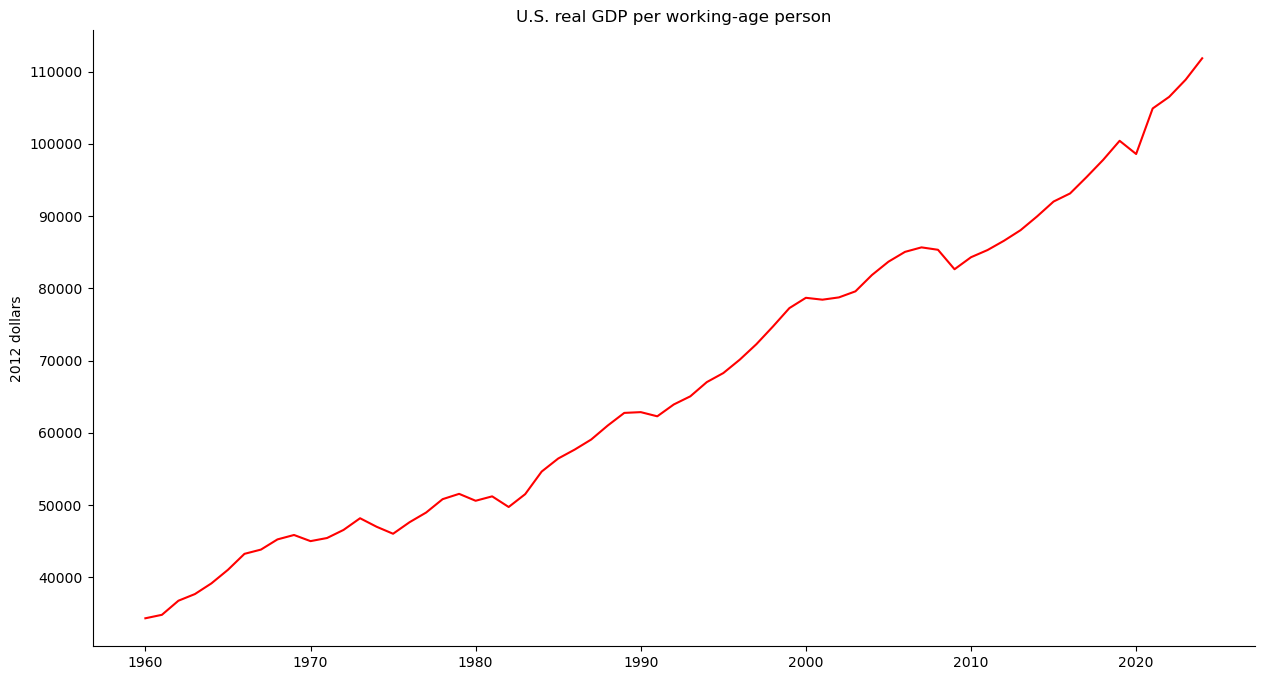

In [ ]:
fig, ax = plt.subplots(figsize=myfigsize)

ax.plot(fred.index, fred['gdp_wap'], color='red')

ax.set_ylabel('2012 dollars')
ax.set_title('U.S. real GDP per working-age person')

sns.despine(ax=ax)

plt.show()

\[Note: I downloaded the 'vix.csv' data from the previous lecture using the following line
```python
vix = web.DataReader('VIXCLS', 'fred', start='1990-01-01', end='1990-10-21' )
```
and messed up the date formatting.\]

### Stooq for indexes

Stooq provides historical pricing for indexes ([docs](https://pandas-datareader.readthedocs.io/en/latest/readers/stooq.html)). Let's grab the data for the Dow Jones Industrial Index. The ticker symbol for the Dow is '^DJI'. 

In [ ]:
# If I do not pass a start or end, it gives the last 5 years. 

dj = web.DataReader('^DJI', 'stooq') # The Dow
sp = web.DataReader('^SPX', 'stooq') # The S&P 500

In [ ]:
print(sp.head(2))
print(sp.tail(2))

               Open     High     Low    Close        Volume
Date                                                       
2025-10-01  6664.92  6718.48  6656.2  6711.20  3.487365e+09
2025-09-30  6656.19  6691.25  6641.0  6688.46  3.486015e+09
               Open     High      Low    Close        Volume
Date                                                        
2020-10-06  3408.74  3431.56  3354.54  3360.97  2.551092e+09
2020-10-05  3367.27  3409.57  3367.27  3408.60  2.040746e+09


In [ ]:
print(dj.head(2))
print(dj.tail(2))

                Open      High       Low     Close       Volume
Date                                                           
2025-10-01  46366.78  46528.78  46276.39  46441.10  515516106.0
2025-09-30  46282.63  46425.30  46103.39  46397.89  445852661.0
                Open      High       Low     Close       Volume
Date                                                           
2020-10-06  28214.24  28354.48  27728.03  27772.76  488795508.0
2020-10-05  27825.42  28162.64  27825.42  28148.64  363078980.0


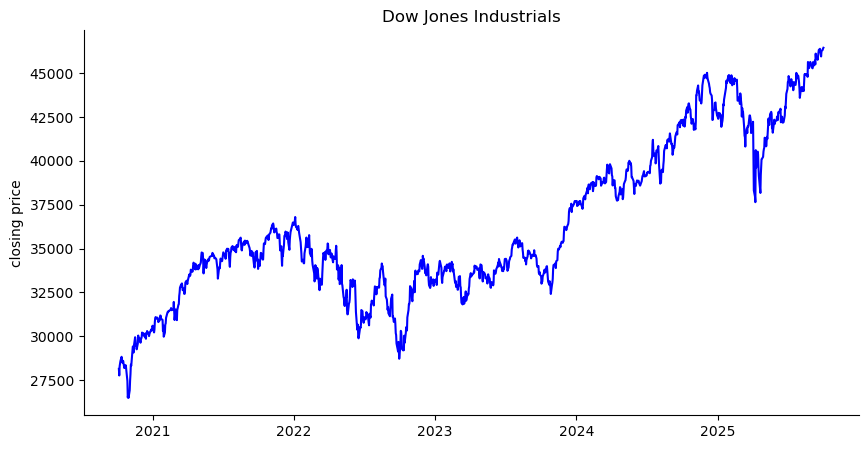

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(dj.index, dj['Close'], color='blue')

ax.set_ylabel('closing price')
ax.set_title('Dow Jones Industrials')

sns.despine(ax=ax)

plt.show()

### Adding the last observation notation

When I am working with an api, I sometimes like to keep track of the latest observation, since it can change when I rerun the code in the future. Let's get the last date from our DataFrame.

In [ ]:
# First, look for the most recent observation's index.
dj.tail(1).index

DatetimeIndex(['2020-10-05'], dtype='datetime64[ns]', name='Date', freq=None)

In [ ]:
# Oops, the data is ordered from most recent to least.
# So the most recent is at the head. Note that it is a DatetimeIndex
dj.head(1).index

DatetimeIndex(['2025-10-01'], dtype='datetime64[ns]', name='Date', freq=None)

In [ ]:
# That's better. Second, the date attribute of the index gives us an array with the datetime in it. 
dj.head(1).index.date

array([datetime.date(2025, 10, 1)], dtype=object)

In [ ]:
# Third, there is only one observation, so access it using [0].
dj.head(1).index.date[0]

datetime.date(2025, 10, 1)

Now I have a datetime object. We know what to do with those. Now my figure will automatically update the text with the correct date.

The data is daily.

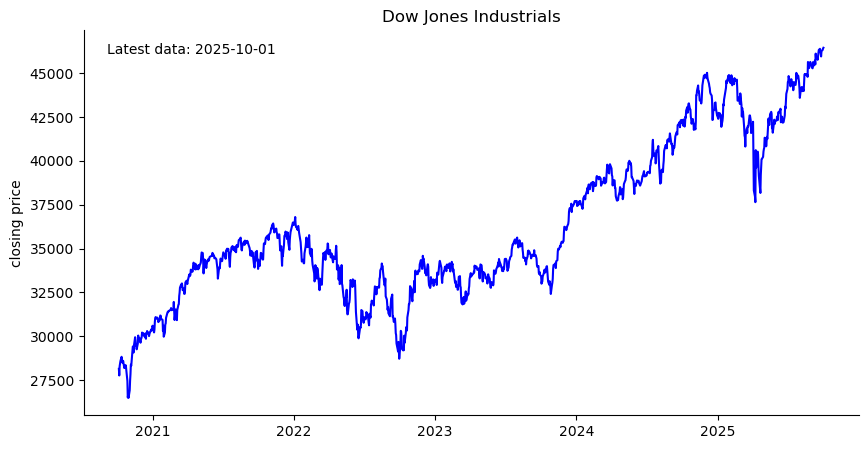

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(dj.index, dj['Close'], color='blue',
       label = 'Latest data: {}'.format(dj.head(1).index.date[0].strftime('%Y-%m-%d')))

ax.set_ylabel('closing price')
ax.set_title('Dow Jones Industrials')

sns.despine(ax=ax)

ax.legend(frameon=False, handlelength=0)                   

plt.show()

In [ ]:
# Can you think of an approach that's robust to sort order?
# What does the following do?
dj.index.max()

Timestamp('2025-10-01 00:00:00')

In [ ]:
## API Requests with Time Delays

With multiple API requests, you may want to set a time delay between requests. I can think of two reasons for doing this:

1. API servers often limit the number of requests a user can make to an API within a specific time frame. This practice is called "rate limiting."
2. You want to update a figure to include the most recent data with some regular frequency (say, once per day). Some researchers use this approach to build their own panel datasets.

We'll deal with the first issue later in the semester. For now, let's focus on creating a figure that auto-updates with the most recent data.

To do this, we'll need to tell python when to start an stop executing code. Let's use the time package to import `sleep`.

In [ ]:
from time import sleep

Let's use sleep to print the current time every second for 10 seconds.

In [ ]:
t=1
while t<=10:
    print('waiting 1 second...')
    print(dt.datetime.now())
    # the input is in seconds
    sleep(1)
    #update the counter
    t=t+1

waiting 1 second...
2025-10-02 13:09:17.420207
waiting 1 second...
2025-10-02 13:09:18.426009
waiting 1 second...
2025-10-02 13:09:19.430740
waiting 1 second...
2025-10-02 13:09:20.432177
waiting 1 second...
2025-10-02 13:09:21.437365
waiting 1 second...
2025-10-02 13:09:22.443357
waiting 1 second...
2025-10-02 13:09:23.444641
waiting 1 second...
2025-10-02 13:09:24.452959
waiting 1 second...
2025-10-02 13:09:25.459115
waiting 1 second...
2025-10-02 13:09:26.466066


Notice that the time interval is not *exactly* one second. This is because of the execution runtime. If you are running code that takes a long time relative to the delay interval, you might need to keep track of the runtime and subtract from the `sleep()` duration.

This is not important for our purposes. I'd like to do the following every day for the foreseeable future:
- Download the most recent two weeks of Dow Jones data.
- Make a new plot with the latest data.

Let's start with a test plot. First, we'll pull the data from the most recent two weeks. `.now()` create's a current datetime object, and `.timedelta()` allows us to reference datetime intervals.

In [ ]:
# end date is now (most current)
end=dt.datetime.now()
# start date is two weeks ago
start=dt.datetime.now()-dt.timedelta(days = 15)    
# Pull the last two weeks of DJI data from Stooq
dj_cur = web.DataReader('^DJI', 'stooq', start, end)
dj_cur

,Open,High,Low,Close,Volume
Date,,,,,
2025-10-01,46366.78,46528.78,46276.39,46441.10,515516106
2025-09-30,46282.63,46425.30,46103.39,46397.89,445852661
2025-09-29,46306.34,46387.06,46149.05,46316.07,414577507
2025-09-26,46101.45,46353.03,46051.92,46247.29,529292508
2025-09-25,46097.43,46122.42,45785.17,45947.32,578242797
2025-09-24,46368.94,46453.07,46096.39,46121.28,408855651
2025-09-23,46364.11,46714.27,46217.58,46292.78,428415558
2025-09-22,46206.69,46447.13,46035.83,46381.54,461837435
2025-09-19,46211.16,46396.47,46105.02,46315.27,887757802


Now we plot.

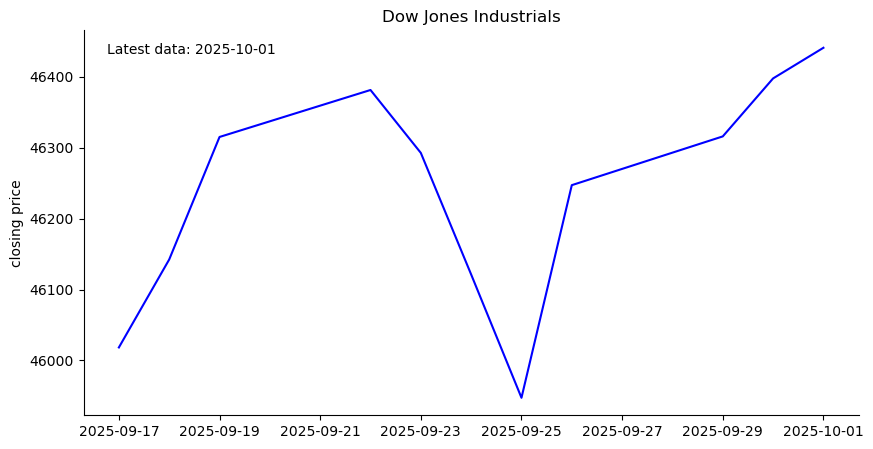

In [ ]:
# Plot the figure
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(dj_cur.index, dj_cur['Close'], color='blue',
       label = 'Latest data: {}'.format(dj.head(1).index.date[0].strftime('%Y-%m-%d')))
       
ax.set_ylabel('closing price')
ax.set_title('Dow Jones Industrials')   
sns.despine(ax=ax)
ax.legend(frameon=False, handlelength=0)  

plt.savefig('dji_current.png', bbox_inches='tight')

plt.show()

Looks pretty good! Now, we can run the same block of code with an infinite loop in python using:
```python
while True :
```
We also need to specify the wait time is a full day. Note that `sleep()` takes in an argument in seconds.

In [ ]:
wait_time = 86400

KeyboardInterrupt: 

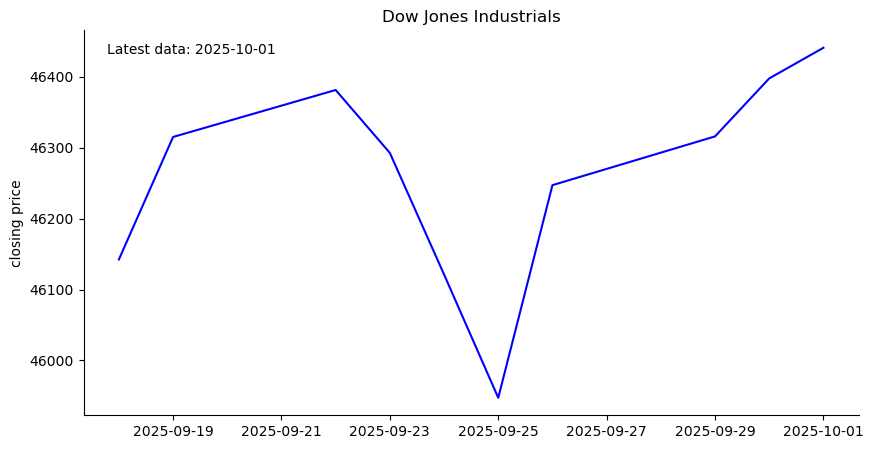

In [ ]:
# Infinite loop
while True:
    # end date is now (most current)
    end=dt.datetime.now()
    # start date is two weeks ago
    start=dt.datetime.now()-dt.timedelta(days = 14)    
    # Pull the last two weeks of DJI data from Stooq
    dj_cur = web.DataReader('^DJI', 'stooq', start, end)
    
    # Plot the figure
    fig, ax = plt.subplots(figsize=(10,5))
    ax.plot(dj_cur.index, dj_cur['Close'], color='blue',
            label = 'Latest data: {}'.format(dj.head(1).index.date[0].strftime('%Y-%m-%d')))
    ax.set_ylabel('closing price')
    ax.set_title('Dow Jones Industrials')   
    sns.despine(ax=ax)
    ax.legend(frameon=False, handlelength=0) 
    
    plt.savefig('dji_current.png', bbox_inches='tight')
    #plt.show()
    
    # wait a full day
#     sleep(wait_time)

If you wait a day without interrupting the execution of the code, you should see an updated figure.

I'll admit that using sleep is a bit clunky, as it requires a very long execution of code. If the code execution stops for any reason, then the updating also stops. There are ways around this, like using [crontab](https://pypi.org/project/crontab/) to schedule tasks. This is beyond our scope, but can be really useful in certain contexts.

For some applications, you might also want to update the name of the output figure each day, rather than simply overwriting the same file. A simple approach would be to include the current date in the figure name. 

## Practice: APIs

Take a few minutes and try the following. Feel free to chat with those around if you get stuck.

How has inflation in the United States evolved over the last 60 years? Let's investigate.

1. Go the FRED website and find the code for the 'Consumer price index for all urban consumers: All items less food and energy'.
2. Use the api to get the data from 1960 to the most recent.

3. Confirm that the frequency of the data is monthly. The inflation rate that is usually reported is calculated *annually*. Compute the annual growth rate of CPI&mdash;the annual inflation rate?

   \[Hint: Check the documentation for `.pct_change()`. Consider using `periods`. How many `NaN` values result?\]

4. Plot the annual inflation rate. What patterns do you see? 

5. Annotate the decrease in inflation around 1983 as 'Volcker disinflation'.

None


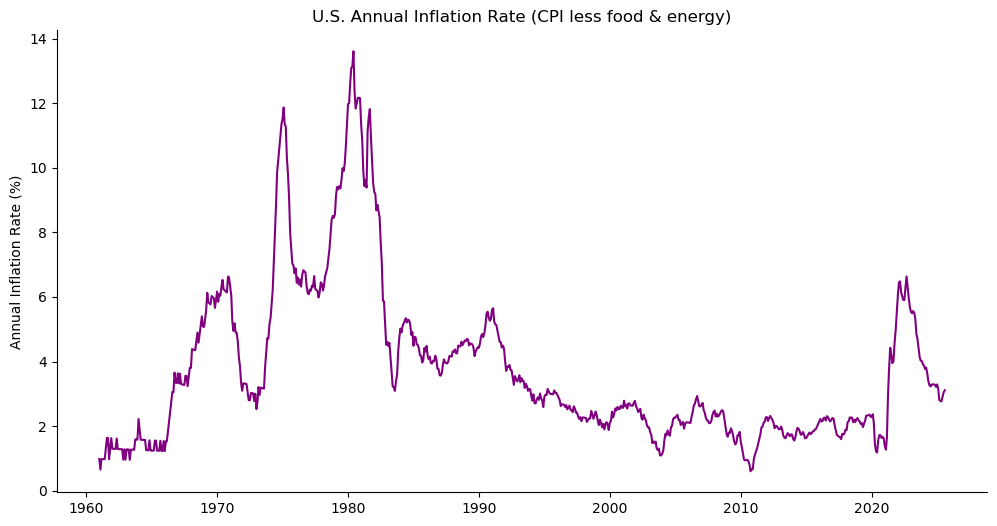

In [ ]:
# 1. FRED code for CPI less food and energy: 'CPILFESL'
cpi_code = 'CPILFESL'

cpi = web.DataReader(cpi_code, 'fred', start='1960-01-01')

print(cpi.index.freq)  

cpi['annual_inflation'] = cpi[cpi_code].pct_change(periods=12) * 100

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(cpi.index, cpi['annual_inflation'], color='purple')
ax.set_ylabel('Annual Inflation Rate (%)')
ax.set_title('U.S. Annual Inflation Rate (CPI less food & energy)')



sns.despine(ax=ax)
plt.show()

## Data without datareader

Some data providers have apis that do not have packages written for them. These apis take a bit more work, including figuring out how to provide the search terms. 

Let's look at the Census Bureau's trade data api. The Census (like many of the national statistical agencies) has an api that takes a bit of work to set up. 

The documentation: https://www.census.gov/foreign-trade/reference/guides/Guide%20to%20International%20Trade%20Datasets.pdf

We are going to retrieve data on the value of U.S. imports of goods, classified by the Harmonized Sytem, from Canada. 

We start with an *endpoint*. Think of it as the address of the server that we want to ask for data (query). Then we build up a string with the requests of the data we need.

In [ ]:
# This is the harmonized system endpoint. I learned this from reading the documentation.

base_url = 'https://api.census.gov/data/timeseries/intltrade/imports/hs?'

For this particular api (they are all different...read the docs) we need to specify which variables we want, at what level of disaggregation we want the data reported, which countries we want imports from, and from what time period. 

In [ ]:
variables = 'GEN_VAL_MO,I_COMMODITY'  # general merchandise value, classification number
level = 'HS10'                        # 10-digit harmonized system classification
country = '1220'                      # Canada
dates = '2020-01'                     # 2021-01

Now we build the url that asks for the data. This is a string. 

* We use `=` to specify the parameters
* We use `&` to add together the different conditional statements

In [ ]:
query = base_url + 'get=' + variables + '&COMM_LVL=' + level + '&CTY_CODE=' + country + '&time=' + dates
query

'https://api.census.gov/data/timeseries/intltrade/imports/hs?get=GEN_VAL_MO,I_COMMODITY&COMM_LVL=HS10&CTY_CODE=1220&time=2020-01'

Copy url (without the quotes) and put it into a web browser. What do you get?

We use the requests package to get the url contents through python ([docs](https://requests.readthedocs.io/en/latest/)). 

In [ ]:
import requests
response = requests.get(query)
type(response)

requests.models.Response

The `Response` object has an attribute `.status_code` which we can check. Status codes are listed [here](https://en.wikipedia.org/wiki/List_of_HTTP_status_codes).

In [ ]:
response.status_code

200

Success. 

Okay, now we have the data...how do we get it into a DataFrame? `Response.content` looks promising...

In [ ]:
response.content

b'[["GEN_VAL_MO","I_COMMODITY","COMM_LVL","CTY_CODE","time"],\n["66733","9504400000","HS10","1220","2020-01"],\n["8259","9616100000","HS10","1220","2020-01"],\n["342814","9504500000","HS10","1220","2020-01"],\n["41455","9504904000","HS10","1220","2020-01"],\n["195926","9504906000","HS10","1220","2020-01"],\n["2480","9504909040","HS10","1220","2020-01"],\n["43287","9504909060","HS10","1220","2020-01"],\n["23806","9504909080","HS10","1220","2020-01"],\n["5783","9505105020","HS10","1220","2020-01"],\n["14370","9505902000","HS10","1220","2020-01"],\n["23697","9505904000","HS10","1220","2020-01"],\n["754815","9505906000","HS10","1220","2020-01"],\n["3000","9506114010","HS10","1220","2020-01"],\n["79863","9506114080","HS10","1220","2020-01"],\n["63986","9506116000","HS10","1220","2020-01"],\n["11633","9506198080","HS10","1220","2020-01"],\n["467647","9506290080","HS10","1220","2020-01"],\n["2679","9506310000","HS10","1220","2020-01"],\n["643568","9506390080","HS10","1220","2020-01"],\n["2722

That gave use the data formatted for text&mdash;what we saw in the browser. Let's try again.

JSON stands for [JavaScript Object Notation](https://en.wikipedia.org/wiki/JSON) and is a format that is commonly used to store data transmitted on the internet. The `.json()` method of the response object tries to convert the content of the webpage into a standard format. 

In [ ]:
data = response.json()
data

[['GEN_VAL_MO', 'I_COMMODITY', 'COMM_LVL', 'CTY_CODE', 'time'],
 ['66733', '9504400000', 'HS10', '1220', '2020-01'],
 ['8259', '9616100000', 'HS10', '1220', '2020-01'],
 ['342814', '9504500000', 'HS10', '1220', '2020-01'],
 ['41455', '9504904000', 'HS10', '1220', '2020-01'],
 ['195926', '9504906000', 'HS10', '1220', '2020-01'],
 ['2480', '9504909040', 'HS10', '1220', '2020-01'],
 ['43287', '9504909060', 'HS10', '1220', '2020-01'],
 ['23806', '9504909080', 'HS10', '1220', '2020-01'],
 ['5783', '9505105020', 'HS10', '1220', '2020-01'],
 ['14370', '9505902000', 'HS10', '1220', '2020-01'],
 ['23697', '9505904000', 'HS10', '1220', '2020-01'],
 ['754815', '9505906000', 'HS10', '1220', '2020-01'],
 ['3000', '9506114010', 'HS10', '1220', '2020-01'],
 ['79863', '9506114080', 'HS10', '1220', '2020-01'],
 ['63986', '9506116000', 'HS10', '1220', '2020-01'],
 ['11633', '9506198080', 'HS10', '1220', '2020-01'],
 ['467647', '9506290080', 'HS10', '1220', '2020-01'],
 ['2679', '9506310000', 'HS10', '12

This looks like a nested list. The first sub-list is the column headers. Each following sub-list is a row of data. 

In [ ]:
data[0]

['GEN_VAL_MO', 'I_COMMODITY', 'COMM_LVL', 'CTY_CODE', 'time']

In [ ]:
data[1]

['66733', '9504400000', 'HS10', '1220', '2020-01']

In [ ]:
imports = pd.DataFrame(data[1:], columns=data[0])
imports.head()

,GEN_VAL_MO,I_COMMODITY,COMM_LVL,CTY_CODE,time
0,66733,9504400000,HS10,1220,2020-01
1,8259,9616100000,HS10,1220,2020-01
2,342814,9504500000,HS10,1220,2020-01
3,41455,9504904000,HS10,1220,2020-01
4,195926,9504906000,HS10,1220,2020-01


That took more work than pandas datareader, but wasn't terrible. Now that we know how to use this api, we can easily download exactly what we need in a programatic way. 

## Practice: APIs on hard mode

Let's try some more downloads from Census. 

1. Try this string in a browser:

```python
'https://api.census.gov/data/timeseries/intltrade/imports/hs?get=GEN_VAL_MO,CTY_NAME&CTY_CODE=2010&time=from+2015-01'
```
   What kind of data is this? What is the unit of observation?


2. Use `requests.get()` to retrieve the contents of the webpage at the url. 
3. Check the status code. Was this successful? 

4. Use the `.json()` method of the response to turn the data into nested lists. 
5. Turn the nested lists into a DataFrame.
6. Check the dtypes. Make the dates datetime and the GEN_VAL_MO float.  

7. Plot imports from Mexico with time on the x-axis.  Does anything stand out?

8. Retrieve the content at this url using `requests.get()`. What is the status code?

```python
'https://api.census.gov/data/timeseries/intltrade/imports/hs?get=GEN_VAL_MO,CTY_NAME&CTY_CODE=5070'
```



9. What does the status code mean? Paste the link into the browser. 
10. Then, try the `.content` attribute of your response object. 